# Tutorial 2 - Least Squares method
**Conditioning, SVD, Tikhonov Regularisation, and the L-curve**

Student-facing notebook · Google Colab compatible · 50–60 minutes · run the cells top to bottom

## Learning objectives
By the end of this tutorial you should be able to:
- Formulate inverse problems as least-squares problems and derive the normal equations.
- Explain conditioning and noise amplification.
- Use the singular value decomposition (SVD) and the **Picard plot** to diagnose poorly constrained directions.
- Implement truncated SVD (TSVD) and Tikhonov regularisation, and compare their *filter functions*.
- Interpret an L-curve, locate its corner numerically, and understand its limitations.

**Central idea:** a solution that fits the observations well is not necessarily a reliable estimate of the unknown parameters.

**Roadmap**

| Section | Question it answers |
|---|---|
| 1–2 | What is least squares, and what does it guarantee? |
| 3 | When and why does it fail? |
| 4 | Which directions in parameter space are the problem? |
| 5–6 | How do TSVD and Tikhonov repair it? |
| 7 | How do we choose the regularisation strength? |
| 8–10 | How do the methods compare, and how does this connect to heat conduction? |

## 1. The inverse problem

A linear inverse problem is often written as

$$
\mathbf b = A\mathbf x + \boldsymbol\varepsilon,
$$

where $A$ is the forward operator, $\mathbf x$ contains the unknown parameters, $\mathbf b$ contains the observations, and $\boldsymbol\varepsilon$ represents measurement or modelling error.

Real observations are noisy, so an exact solution may not exist. We seek parameters whose predictions are as close as possible to the data.

**Notation used throughout:** $m$ = number of observations, $n$ = number of parameters, $\|\cdot\|$ = the Euclidean 2-norm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Section 2 uses its own generator so that re-running cells out of order
# never changes the data used in later sections.
rng_small = np.random.default_rng(7)

## 2. Least squares and normal equations

Define the residual $\mathbf r = A\mathbf x - \mathbf b$. Least squares minimises

$$
J(\mathbf x) = \|A\mathbf x - \mathbf b\|_2^2 .
$$

Differentiating gives $\nabla_{\mathbf x} J = 2A^\mathsf T(A\mathbf x - \mathbf b)$. Setting this to zero gives the **normal equations**:

$$
A^\mathsf T A\,\mathbf x = A^\mathsf T \mathbf b .
$$

If $A^\mathsf T A$ is invertible, the formal solution is $(A^\mathsf T A)^{-1}A^\mathsf T\mathbf b$. In code, avoid explicitly calculating matrix inverses. The normal equations are easy to derive, but forming $A^\mathsf T A$ can worsen numerical conditioning (we will see this in Section 3).

First, a well-behaved example: 30 equations, 3 unknowns.

True parameters:         [ 2.  -1.   0.5]
Normal-equation result:  [ 2.0045 -1.0054  0.5172]
np.linalg.lstsq result:  [ 2.0045 -1.0054  0.5172]
Residual norm:           0.22070907753590552
A.T @ residual:          [ 0. -0. -0.]   <- zero up to round-off


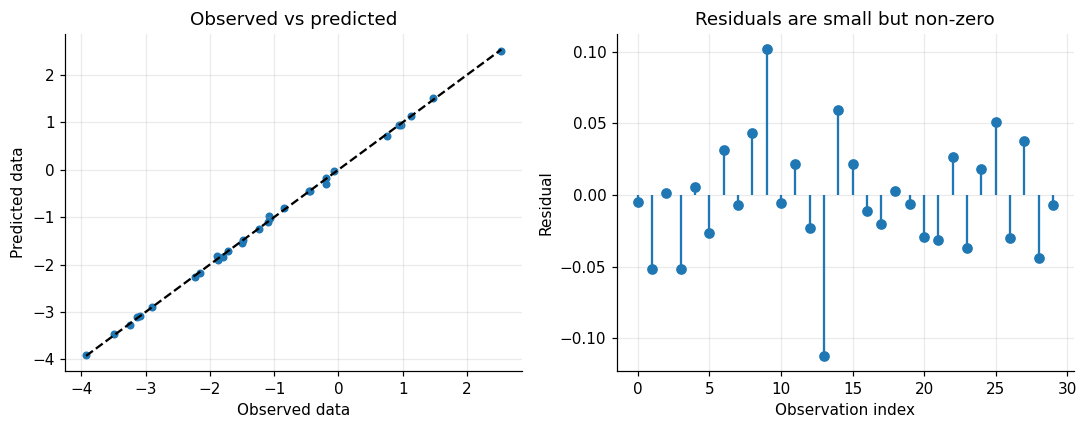

In [2]:
A_small = rng_small.normal(size=(30, 3))
x_true_small = np.array([2.0, -1.0, 0.5])
b_small = A_small @ x_true_small + 0.05 * rng_small.normal(size=30)

x_normal = np.linalg.solve(A_small.T @ A_small, A_small.T @ b_small)
x_lstsq, *_ = np.linalg.lstsq(A_small, b_small, rcond=None)
r_small = A_small @ x_lstsq - b_small

print("True parameters:        ", x_true_small)
print("Normal-equation result: ", x_normal)
print("np.linalg.lstsq result: ", x_lstsq)
print("Residual norm:          ", np.linalg.norm(r_small))
print("A.T @ residual:         ", A_small.T @ r_small, "  <- zero up to round-off")

pred = A_small @ x_lstsq
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(b_small, pred, s=18)
lo, hi = min(b_small.min(), pred.min()), max(b_small.max(), pred.max())
axes[0].plot([lo, hi], [lo, hi], "k--")
axes[0].set(xlabel="Observed data", ylabel="Predicted data", title="Observed vs predicted")
axes[1].stem(r_small, basefmt=" ")
axes[1].set(xlabel="Observation index", ylabel="Residual", title="Residuals are small but non-zero")
plt.tight_layout(); plt.show()

At the least-squares solution, the residual is orthogonal to every column of $A$:

$$
A^\mathsf T(A\mathbf x_{LS} - \mathbf b) = 0 .
$$

Geometrically, $A\mathbf x_{LS}$ is the orthogonal projection of the data onto the column space of $A$.

### Checkpoint 1
1. Why is this system overdetermined?
2. Does least squares generally make every residual zero?
3. Why is `np.linalg.lstsq` preferable to explicitly calculating an inverse?

<details>
<summary>Show answers (try first!)</summary>

1. There are $m=30$ equations but only $n=3$ unknowns, so there are more constraints than free parameters.
2. No. Zero residual would require $\mathbf b$ to lie exactly in the column space of $A$. With noisy data it does not; least squares gives the *closest* point in that space.
3. An explicit inverse is more expensive and less accurate. `lstsq` uses a stable factorisation (SVD-based) and never forms $A^\mathsf T A$, which squares the condition number.
</details>

## 3. Conditioning and noise amplification

The 2-norm condition number of a full-column-rank matrix is

$$
\kappa_2(A) = \frac{\sigma_{\max}}{\sigma_{\min}},
$$

where $\sigma_i$ are the singular values. A large condition number indicates that some parameter directions are poorly constrained. For full-column-rank $A$, $\kappa_2(A^\mathsf T A) = \kappa_2(A)^2$ in exact arithmetic.

**Our test problem.** The helper below builds $A = Q_1\,\mathrm{diag}(\sigma)\,V^\mathsf T$ with singular values spanning six orders of magnitude. The columns of $V$ are cosine modes of increasing frequency, so the directions that $A$ barely sees are the *oscillatory* ones. This mimics smoothing forward operators (such as heat conduction), where fine-scale detail is washed out before it reaches the sensors. The true parameters are a smooth, phase-shifted sine wave.

The helper is a function so that you can easily change `sigma_min` and `noise_level` in the exercises.

In [3]:
def make_problem(m=80, n=20, sigma_min=1e-6, noise_level=1e-4, seed=7):
    rng = np.random.default_rng(seed)
    Q1, _ = np.linalg.qr(rng.normal(size=(m, n)))          # data-space directions
    j = np.arange(n)
    V = np.sqrt(2 / n) * np.cos(np.pi * np.outer(j + 0.5, j) / n)
    V[:, 0] /= np.sqrt(2)                                   # orthonormal cosine basis
    sigma = np.logspace(0, np.log10(sigma_min), n)
    A = Q1 @ np.diag(sigma) @ V.T
    x_true = np.sin(np.linspace(0, 2 * np.pi, n) + 1.0)     # smooth truth (phase shift avoids
                                                            # accidental symmetry with the cosine modes)
    b_clean = A @ x_true
    b_noisy = b_clean + noise_level * rng.normal(size=m)
    return A, x_true, b_clean, b_noisy

noise_level = 1e-4
A, x_true, b_clean, b_noisy = make_problem(noise_level=noise_level)
m, n = A.shape
print(f"A is {m} x {n},  cond(A) = {np.linalg.cond(A):.3e}")

A is 80 x 20,  cond(A) = 1.000e+06


### 3.1 Why the normal equations are risky

Because $\kappa_2(A^\mathsf T A) = \kappa_2(A)^2$, forming $A^\mathsf T A$ squares the sensitivity to round-off. We test this with **noise-free** data, so any error is purely numerical.

In [4]:
x_ne = np.linalg.solve(A.T @ A, A.T @ b_clean)
x_ls = np.linalg.lstsq(A, b_clean, rcond=None)[0]

print(f"cond(A)        = {np.linalg.cond(A):.3e}")
print(f"cond(A.T @ A)  = {np.linalg.cond(A.T @ A):.3e}   (roughly cond(A)^2)")
print()
print(f"Normal equations, clean data: parameter error = {np.linalg.norm(x_ne - x_true):.3e}")
print(f"np.linalg.lstsq,  clean data: parameter error = {np.linalg.norm(x_ls - x_true):.3e}")

cond(A)        = 1.000e+06
cond(A.T @ A)  = 1.000e+12   (roughly cond(A)^2)

Normal equations, clean data: parameter error = 2.882e-06
np.linalg.lstsq,  clean data: parameter error = 1.783e-11


Both are accurate here, but the normal equations lose about five more digits. Had $\sigma_{\min}$ been $10^{-8}$, $\kappa_2(A^\mathsf T A)$ would exceed $10^{16}$ and the normal equations would fail outright.

This is a *numerical* problem, and a better algorithm fixes it. The bigger issue is a *statistical* one, which no algorithm can fix without extra assumptions: measurement noise.

### 3.2 Noise amplification

clean-data parameter error = 1.783e-11
noisy-data parameter error = 9.295e+01
data noise norm            = 7.979e-04


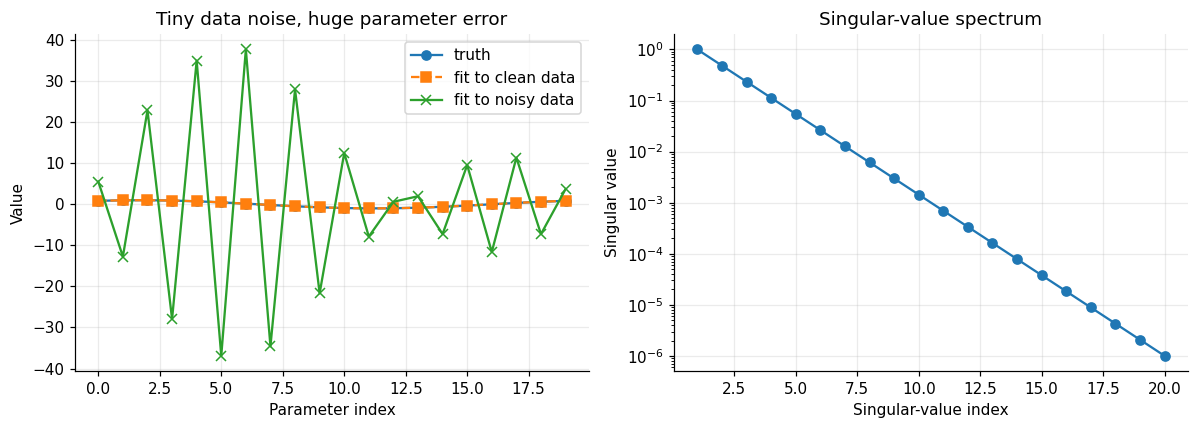

In [5]:
x_clean = np.linalg.lstsq(A, b_clean, rcond=None)[0]
x_noisy = np.linalg.lstsq(A, b_noisy, rcond=None)[0]
print(f"clean-data parameter error = {np.linalg.norm(x_clean - x_true):.3e}")
print(f"noisy-data parameter error = {np.linalg.norm(x_noisy - x_true):.3e}")
print(f"data noise norm            = {np.linalg.norm(b_noisy - b_clean):.3e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(x_true, "o-", label="truth")
axes[0].plot(x_clean, "s--", label="fit to clean data")
axes[0].plot(x_noisy, "x-", label="fit to noisy data")
axes[0].set(xlabel="Parameter index", ylabel="Value", title="Tiny data noise, huge parameter error")
axes[0].legend()
axes[1].semilogy(np.arange(1, n + 1), np.linalg.svd(A, compute_uv=False), "o-")
axes[1].set(xlabel="Singular-value index", ylabel="Singular value", title="Singular-value spectrum")
plt.tight_layout(); plt.show()

The data noise has norm of order $10^{-3}$, yet the parameter error is of order $10^{2}$: an amplification of roughly *five orders of magnitude*, and the fit to the noisy data is visually useless.

### Noise sweep
A small residual does not necessarily mean that the parameter estimate is accurate. The solver fits the data; it cannot inherently distinguish signal from noise. To reduce run-to-run scatter we repeat each noise level 20 times and report the median.

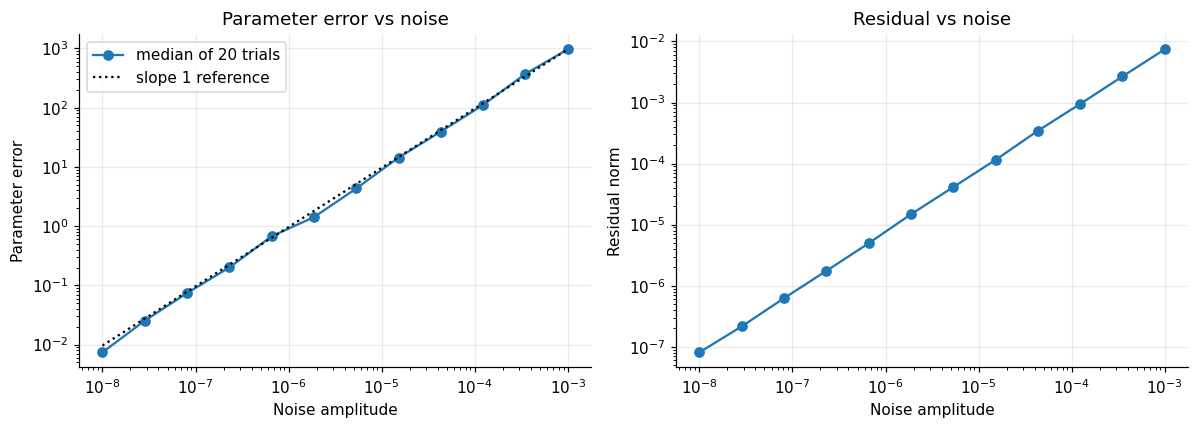

In [6]:
rng_sweep = np.random.default_rng(1)
noise_levels = np.logspace(-8, -3, 12)
n_trials = 20
param_err, resid = [], []
for level in noise_levels:
    errs, ress = [], []
    for _ in range(n_trials):
        b_p = b_clean + level * rng_sweep.normal(size=m)
        x_est = np.linalg.lstsq(A, b_p, rcond=None)[0]
        errs.append(np.linalg.norm(x_est - x_true))
        ress.append(np.linalg.norm(A @ x_est - b_p))
    param_err.append(np.median(errs)); resid.append(np.median(ress))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].loglog(noise_levels, param_err, "o-", label="median of 20 trials")
axes[0].loglog(noise_levels, noise_levels * param_err[-1] / noise_levels[-1], "k:", label="slope 1 reference")
axes[0].set(xlabel="Noise amplitude", ylabel="Parameter error", title="Parameter error vs noise")
axes[0].legend()
axes[1].loglog(noise_levels, resid, "o-")
axes[1].set(xlabel="Noise amplitude", ylabel="Residual norm", title="Residual vs noise")
plt.tight_layout(); plt.show()

**Read the plots.** The residual stays tiny (it is always about the size of the noise itself), so the fit *looks* excellent. Yet the parameter error is huge. The error also grows in proportion to the noise (slope 1 on log-log axes), which is the signature of a *linear* amplification factor. Section 4 identifies that factor.

## 4. Singular value decomposition (SVD)

The SVD factors the forward matrix:

$$
A = U\Sigma V^\mathsf T .
$$

The columns of $U$ describe data-space directions; columns of $V$ describe parameter-space directions; singular values quantify how strongly each direction affects observations. The least-squares solution is

$$
\mathbf x_{LS} = \sum_{i=1}^{n} \frac{\mathbf u_i^\mathsf T \mathbf b}{\sigma_i}\,\mathbf v_i ,
$$

so each component is divided by its singular value, and **small singular values amplify noise**.

In [7]:
U, s, Vt = np.linalg.svd(A, full_matrices=False)
A_reconstructed = U @ np.diag(s) @ Vt
print("Relative SVD reconstruction error:",
      np.linalg.norm(A - A_reconstructed) / np.linalg.norm(A))
x_svd = Vt.T @ ((U.T @ b_noisy) / s)
x_lstsq_check = np.linalg.lstsq(A, b_noisy, rcond=None)[0]
print("Difference from np.linalg.lstsq:  ", np.linalg.norm(x_svd - x_lstsq_check))

Relative SVD reconstruction error: 1.5850025320778386e-15
Difference from np.linalg.lstsq:   2.426568495072825e-11


### 4.1 What do the singular vectors look like?
Small singular values belong to oscillatory parameter patterns. Those are exactly the patterns the data cannot see.

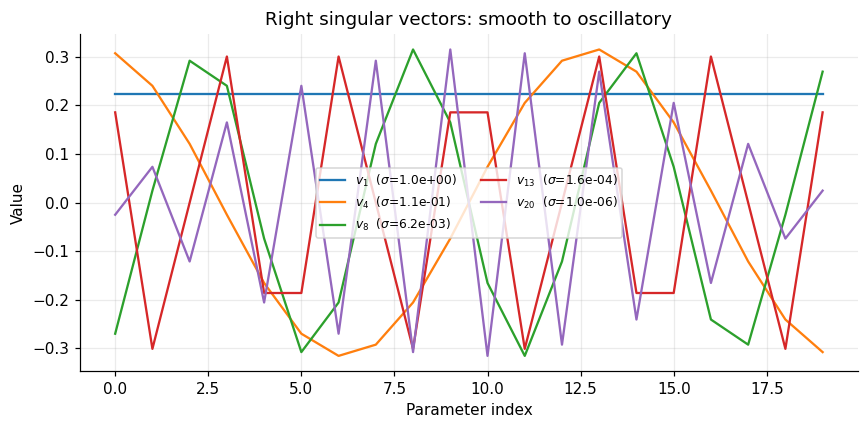

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
for i in [0, 3, 7, 12, 19]:
    ax.plot(Vt[i], label=f"$v_{{{i+1}}}$  ($\\sigma$={s[i]:.1e})")
ax.set(xlabel="Parameter index", ylabel="Value", title="Right singular vectors: smooth to oscillatory")
ax.legend(ncol=2, fontsize=8); plt.tight_layout(); plt.show()

### 4.2 The Picard plot
The most useful diagnostic for a discrete inverse problem plots, against the index $i$:
- the singular values $\sigma_i$,
- the data coefficients $|\mathbf u_i^\mathsf T\mathbf b|$,
- the solution coefficients $|\mathbf u_i^\mathsf T\mathbf b|/\sigma_i$ (what the least-squares solution is actually built from).

For white noise of standard deviation $\delta$, each $|\mathbf u_i^\mathsf T\boldsymbol\varepsilon|$ is about $\delta$, a flat **noise floor**. Signal coefficients decay with $\sigma_i$, so once they sink to the floor, what remains is noise being divided by a tiny number.

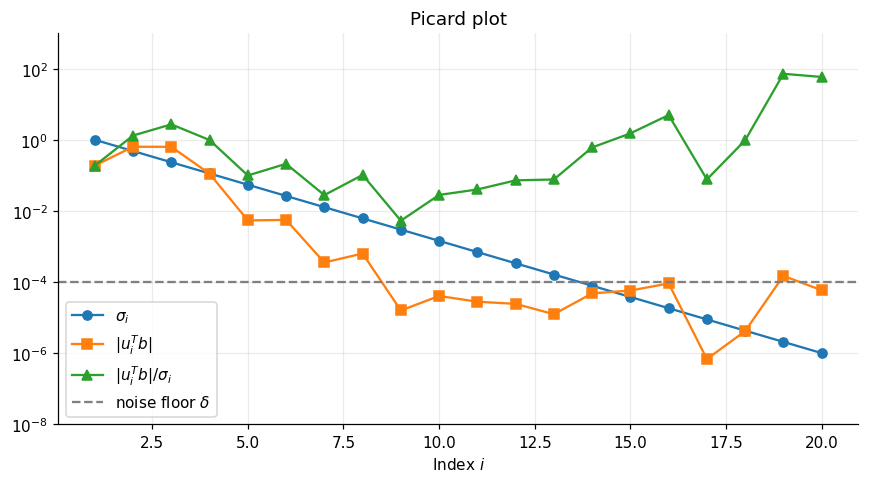

In [9]:
beta = U.T @ b_noisy
idx = np.arange(1, n + 1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(idx, s, "o-", label=r"$\sigma_i$")
ax.semilogy(idx, np.abs(beta), "s-", label=r"$|u_i^T b|$")
ax.semilogy(idx, np.abs(beta) / s, "^-", label=r"$|u_i^T b| / \sigma_i$")
ax.axhline(noise_level, color="gray", ls="--", label=r"noise floor $\delta$")
ax.set(xlabel="Index $i$", title="Picard plot", ylim=(1e-8, 1e3))
ax.legend(); plt.tight_layout(); plt.show()

**Interpretation.** For the first several indices the data coefficients $|\mathbf u_i^\mathsf T\mathbf b|$ sit well above the noise floor and the solution coefficients stay modest. By roughly $i\approx 8$–$10$ the data coefficients are pinned at the floor while $\sigma_i$ keeps falling, so the solution coefficients $|\mathbf u_i^\mathsf T\mathbf b|/\sigma_i$ explode. The index where this happens tells you how many components the data genuinely constrain. This is the idea behind truncation.

### 4.3 Truncated SVD (TSVD)

TSVD discards the smallest singular values. Keeping the largest $k$ values gives

$$
\mathbf x_k = \sum_{i=1}^{k} \frac{\mathbf u_i^\mathsf T\mathbf b}{\sigma_i}\,\mathbf v_i .
$$

This can reduce noise amplification, but choosing too small a rank also discards useful information.

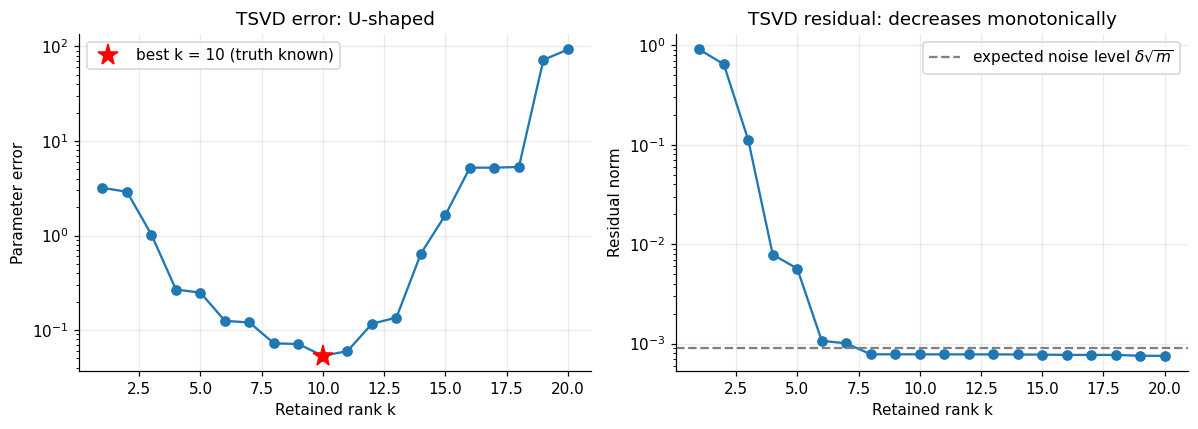

In [10]:
def tsvd_solve(A, b, k):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    if not 1 <= int(k) <= len(s):
        raise ValueError("k must be between 1 and the number of singular values")
    k = int(k)
    return Vt[:k].T @ ((U[:, :k].T @ b) / s[:k])

ranks = np.arange(1, n + 1)
tsvd_errors = np.array([np.linalg.norm(tsvd_solve(A, b_noisy, k) - x_true) for k in ranks])
tsvd_residuals = np.array([np.linalg.norm(A @ tsvd_solve(A, b_noisy, k) - b_noisy) for k in ranks])
k_best = ranks[np.argmin(tsvd_errors)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(ranks, tsvd_errors, "o-")
axes[0].plot(k_best, tsvd_errors[k_best - 1], "r*", ms=14, label=f"best k = {k_best} (truth known)")
axes[0].set(xlabel="Retained rank k", ylabel="Parameter error", title="TSVD error: U-shaped")
axes[0].legend()
axes[1].semilogy(ranks, tsvd_residuals, "o-")
axes[1].axhline(noise_level * np.sqrt(m), color="gray", ls="--", label=r"expected noise level $\delta\sqrt{m}$")
axes[1].set(xlabel="Retained rank k", ylabel="Residual norm", title="TSVD residual: decreases monotonically")
axes[1].legend()
plt.tight_layout(); plt.show()

The error is **U-shaped** (too small $k$ discards signal; too large $k$ keeps amplified noise), while the residual only ever decreases and flattens out at the noise level once $k\gtrsim 7$. Extra components beyond that point fit noise, not signal, so the residual alone can never tell you where to stop. Notice also that the best $k$ lies close to where the Picard plot's data coefficients reach the noise floor (slightly beyond it, since the last few components still carry a little signal).

### Checkpoint 2
1. What does a small singular value mean?
2. Why can TSVD improve parameter accuracy even when the residual increases?
3. Would the best truncation rank necessarily remain the same at a different noise level?

<details>
<summary>Show answers (try first!)</summary>

1. A parameter direction $\mathbf v_i$ that changes the observations only weakly ($\|A\mathbf v_i\|=\sigma_i$). The data barely constrain it, and inverting divides by $\sigma_i$.
2. Least squares gives the smallest possible residual, so removing components can only raise it. But the removed components were mostly noise multiplied by $1/\sigma_i$, so the parameter error falls.
3. No. More noise raises the floor in the Picard plot, which meets the coefficients earlier, so the best $k$ is smaller. Less noise allows a larger $k$.
</details>

## 5. Tikhonov regularisation

Tikhonov regularisation balances data fit against a penalty on solution size:

$$
\mathbf x_\lambda = \arg\min_{\mathbf x}\left[\|A\mathbf x - \mathbf b\|_2^2 + \lambda^2\|\mathbf x\|_2^2\right].
$$

The normal-equation form is

$$
(A^\mathsf T A + \lambda^2 I)\,\mathbf x_\lambda = A^\mathsf T\mathbf b .
$$

Using the SVD,

$$
\mathbf x_\lambda = \sum_i \frac{\sigma_i}{\sigma_i^2+\lambda^2}\,(\mathbf u_i^\mathsf T\mathbf b)\,\mathbf v_i
= \sum_i f_i\,\frac{\mathbf u_i^\mathsf T\mathbf b}{\sigma_i}\,\mathbf v_i,
\qquad f_i = \frac{\sigma_i^2}{\sigma_i^2+\lambda^2}.
$$

The numbers $f_i$ are **filter factors**. Plain least squares has $f_i = 1$ and TSVD has $f_i\in\{0,1\}$ (a hard switch). Tikhonov damps singular directions *continuously*: $f_i\approx 1$ when $\sigma_i\gg\lambda$ and $f_i\approx 0$ when $\sigma_i\ll\lambda$. Larger $\lambda$ means stronger regularisation.

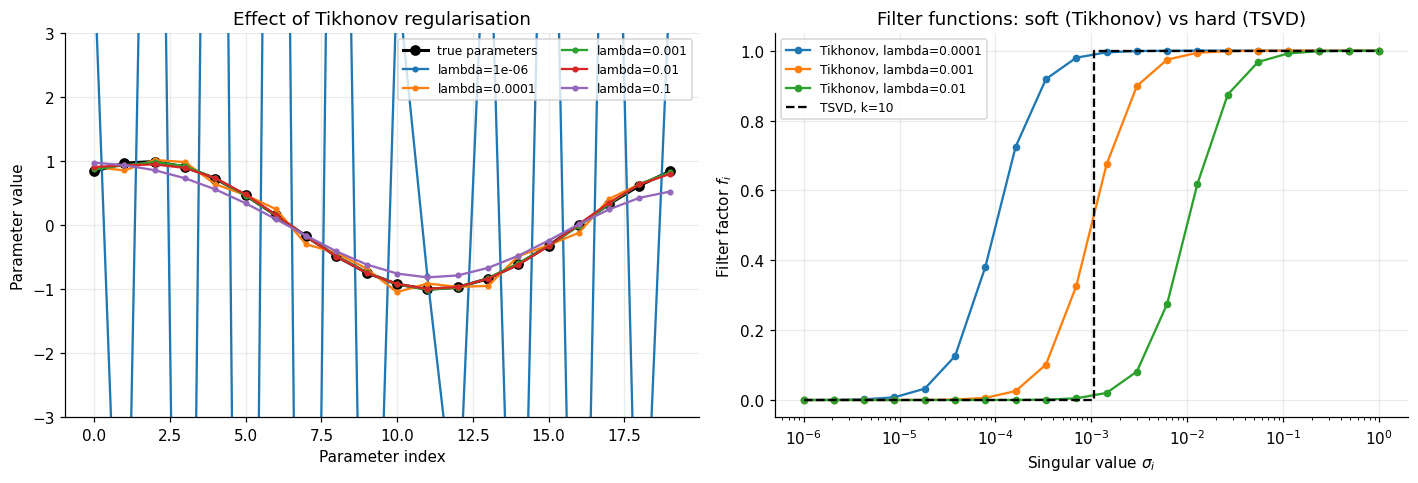

In [11]:
def tikhonov_solve(A, b, lam):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    filt = s / (s**2 + lam**2)
    return Vt.T @ (filt * (U.T @ b))

lambdas_demo = [1e-6, 1e-4, 1e-3, 1e-2, 1e-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x_true, "k-o", label="true parameters", linewidth=2)
for lam in lambdas_demo:
    axes[0].plot(tikhonov_solve(A, b_noisy, lam), ".-", label=f"lambda={lam:g}")
axes[0].set(xlabel="Parameter index", ylabel="Parameter value", title="Effect of Tikhonov regularisation")
axes[0].set_ylim(-3, 3)
axes[0].legend(ncol=2, fontsize=8)

for lam in [1e-4, 1e-3, 1e-2]:
    axes[1].semilogx(s, s**2 / (s**2 + lam**2), "o-", ms=4, label=f"Tikhonov, lambda={lam:g}")
axes[1].step(s[::-1], (np.arange(n, 0, -1) <= 10).astype(float), where="mid",
             color="k", ls="--", label="TSVD, k=10")
axes[1].set(xlabel=r"Singular value $\sigma_i$", ylabel=r"Filter factor $f_i$",
            title="Filter functions: soft (Tikhonov) vs hard (TSVD)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

**Under- vs over-regularisation.** With $\lambda=10^{-6}$ the curve is wild and noise-dominated (under-regularised; it is clipped to the plot window). With $\lambda=10^{-1}$ the solution is smooth but visibly shrunk towards zero, so it underestimates the amplitude of the truth (over-regularised). A good $\lambda$ lies in between; the next section is about finding it *without* knowing the truth.

## 6. Choosing the regularisation parameter: the L-curve

For each $\lambda$, compute the residual norm $\|A\mathbf x_\lambda-\mathbf b\|_2$ and solution norm $\|\mathbf x_\lambda\|_2$. Plot them against each other on logarithmic axes.

The L-curve often has a corner between weak regularisation (small residual, potentially huge solution norm) and strong regularisation (smaller solution norm, larger residual).

The corner is a **heuristic**, not a guarantee of the optimal parameter. It may be ambiguous. We locate it numerically as the point of maximum curvature of the log-log curve. In this synthetic example we know the true solution, so we can also compute the parameter that minimises reconstruction error. **That information is not normally available in a real inverse problem.**

lambda minimising error (truth known): 1.162e-03   error = 0.062
lambda at L-curve corner (data only):  3.181e-04   error = 0.102


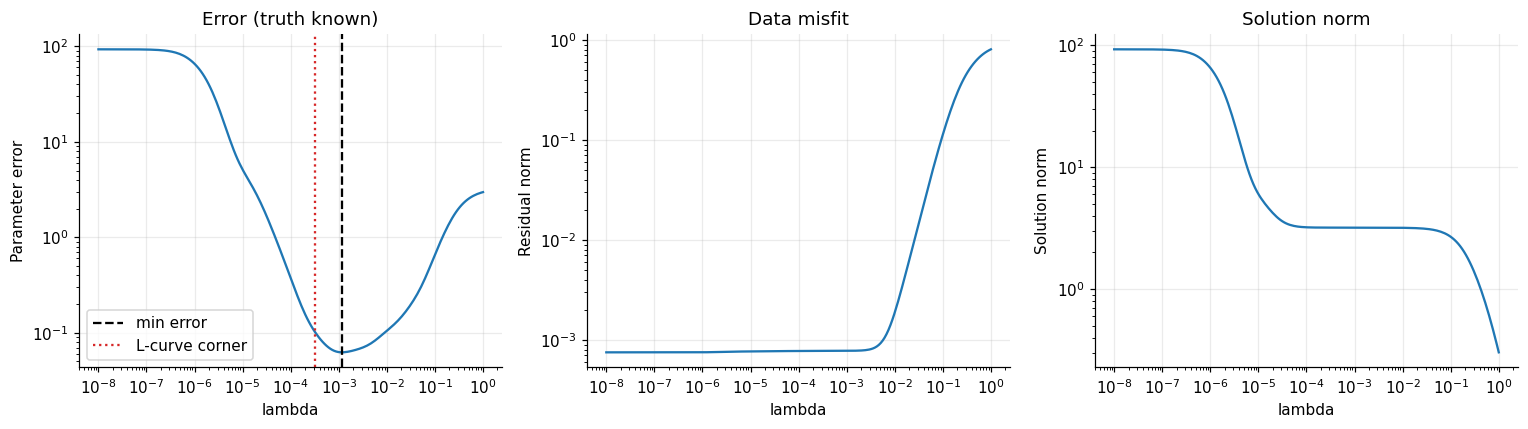

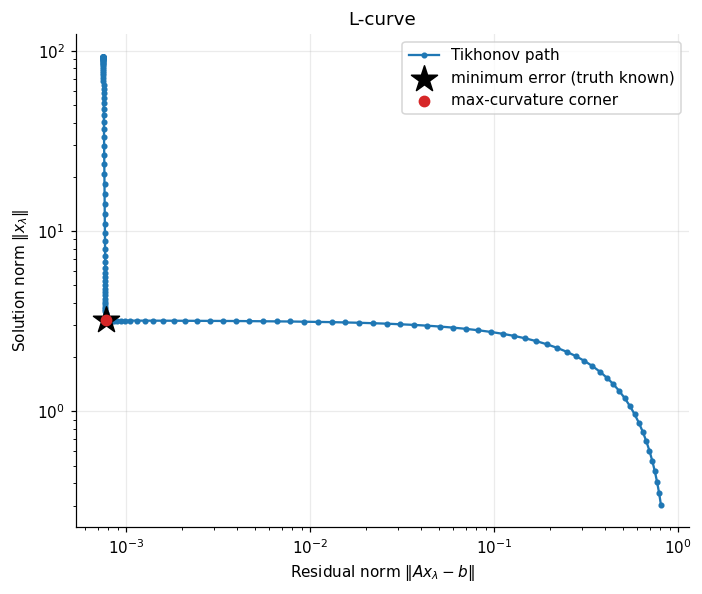

In [12]:
def tikhonov_path(A, b, lambdas):
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    beta = U.T @ b
    sols = np.array([Vt.T @ (s / (s**2 + lam**2) * beta) for lam in lambdas])
    res = np.linalg.norm(sols @ A.T - b, axis=1)
    nrm = np.linalg.norm(sols, axis=1)
    return sols, res, nrm

def lcurve_corner(lambdas, res, nrm):
    t, rho, eta = np.log(lambdas), np.log(res), np.log(nrm)
    d_rho, d_eta = np.gradient(rho, t), np.gradient(eta, t)
    dd_rho, dd_eta = np.gradient(d_rho, t), np.gradient(d_eta, t)
    curvature = (d_rho * dd_eta - dd_rho * d_eta) / (d_rho**2 + d_eta**2) ** 1.5
    interior = slice(2, -2)                     # ignore unreliable end-point derivatives
    return np.argmax(curvature[interior]) + 2

lambdas = np.logspace(-8, 0, 200)
solutions, residuals, solution_norms = tikhonov_path(A, b_noisy, lambdas)
errors = np.linalg.norm(solutions - x_true, axis=1)

best_idx = np.argmin(errors)
corner_idx = lcurve_corner(lambdas, residuals, solution_norms)
lambda_best_truth = lambdas[best_idx]
lambda_corner = lambdas[corner_idx]

print(f"lambda minimising error (truth known): {lambda_best_truth:.3e}   error = {errors[best_idx]:.3f}")
print(f"lambda at L-curve corner (data only):  {lambda_corner:.3e}   error = {errors[corner_idx]:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].loglog(lambdas, errors)
axes[0].axvline(lambda_best_truth, color="black", ls="--", label="min error")
axes[0].axvline(lambda_corner, color="tab:red", ls=":", label="L-curve corner")
axes[0].set(xlabel="lambda", ylabel="Parameter error", title="Error (truth known)"); axes[0].legend()
axes[1].loglog(lambdas, residuals)
axes[1].set(xlabel="lambda", ylabel="Residual norm", title="Data misfit")
axes[2].loglog(lambdas, solution_norms)
axes[2].set(xlabel="lambda", ylabel="Solution norm", title="Solution norm")
plt.tight_layout(); plt.show()

plt.figure(figsize=(6.5, 5.5))
plt.loglog(residuals, solution_norms, "o-", markersize=3, label="Tikhonov path")
plt.scatter(residuals[best_idx], solution_norms[best_idx], marker="*", s=320, color="black",
            zorder=2, label="minimum error (truth known)")
plt.scatter(residuals[corner_idx], solution_norms[corner_idx], marker="o", s=45, color="tab:red",
            zorder=3, label="max-curvature corner")
plt.xlabel(r"Residual norm $\|Ax_\lambda - b\|$")
plt.ylabel(r"Solution norm $\|x_\lambda\|$")
plt.title("L-curve"); plt.legend(); plt.tight_layout(); plt.show()

The corner, found from the data alone, lands close to the truth-optimal $\lambda$ here (the black star and red dot nearly coincide), and the parameter error at the two choices is similar. That is encouraging but **not guaranteed**: for other noise levels, smoother solutions or flatter curves the corner can be badly placed or hard to identify.

### Checkpoint 3
1. Why are the L-curve axes logarithmic?
2. Why is the minimum-error $\lambda$ unavailable in a real experiment?
3. What would you expect to happen to the L-curve corner if the noise level were increased tenfold?

<details>
<summary>Show answers (try first!)</summary>

1. Residual and solution norms vary over many orders of magnitude, and a log scale makes the corner (a change in *relative* behaviour) visible and scale-independent.
2. It requires $\mathbf x_{true}$, which is exactly what we are trying to estimate.
3. The residual at the corner moves up (a larger noise floor) and the corner shifts to a larger $\lambda$, because more of the singular directions are noise-dominated. You can test this with `make_problem(noise_level=1e-3)`.
</details>

## 7. Compare methods

| Method | Main idea | Main limitation |
|---|---|---|
| Normal equations | Solve $A^TAx=A^Tb$ | Can worsen numerical conditioning |
| `np.linalg.lstsq` | Stable least-squares solution | Does not by itself stabilise an ill-posed problem |
| TSVD | Discard small-singular-value directions | Requires a rank choice |
| Tikhonov | Continuously damp unstable directions | Requires a regularisation parameter and suitable penalty |
| L-curve | Inspect residual/solution norm trade-off | Corner may be ambiguous |

Run the comparison below on the same noisy data.

Method                        Parameter error  Relative error   Residual norm
------------------------------------------------------------------------------
Least squares                      9.2952e+01        2909.28%      7.5144e-04
TSVD k=10                          5.3249e-02           1.67%      7.7826e-04
TSVD k=15                          1.6524e+00          51.72%      7.7367e-04
Tikhonov lambda=1e-3               6.2667e-02           1.96%      7.7835e-04
Tikhonov L-curve corner            1.0218e-01           3.20%      7.7719e-04
Tikhonov best with truth           6.2320e-02           1.95%      7.7876e-04


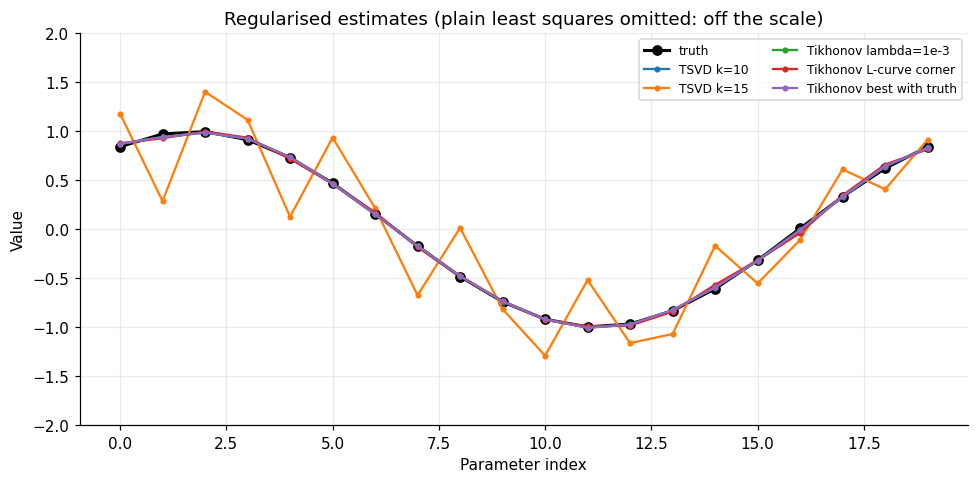

In [13]:
comparison = [
    ("Least squares",               np.linalg.lstsq(A, b_noisy, rcond=None)[0]),
    ("TSVD k=10",                   tsvd_solve(A, b_noisy, 10)),
    ("TSVD k=15",                   tsvd_solve(A, b_noisy, 15)),
    ("Tikhonov lambda=1e-3",        tikhonov_solve(A, b_noisy, 1e-3)),
    ("Tikhonov L-curve corner",     tikhonov_solve(A, b_noisy, lambda_corner)),
    ("Tikhonov best with truth",    tikhonov_solve(A, b_noisy, lambda_best_truth)),
]
print(f"{'Method':28s} {'Parameter error':>16s} {'Relative error':>15s} {'Residual norm':>15s}")
print("-" * 78)
for name, est in comparison:
    err = np.linalg.norm(est - x_true)
    print(f"{name:28s} {err:16.4e} {err/np.linalg.norm(x_true):15.2%} "
          f"{np.linalg.norm(A @ est - b_noisy):15.4e}")

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(x_true, "k-o", lw=2, label="truth")
for name, est in comparison[1:]:
    ax.plot(est, ".-", label=name)
ax.set(xlabel="Parameter index", ylabel="Value", title="Regularised estimates (plain least squares omitted: off the scale)")
ax.set_ylim(-2, 2); ax.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

**Things to notice.**
- Plain least squares has the *smallest* residual and by far the *largest* error. Data fit is not the goal.
- TSVD at $k=15$ is already too aggressive a rank: it keeps components below the noise floor.
- Hand-picking $\lambda=10^{-3}$ and using the L-curve corner give similar, good answers. The best-with-truth entry is an unattainable benchmark.

## 8. Connection to inverse heat conduction

In the earlier tutorial, the unknown may have been one scalar thermal diffusivity $\alpha$. That is a low-dimensional parameter-estimation problem.

Recovering a spatially varying field such as $\alpha(x)$ from limited temperature measurements is harder. After discretisation, it may lead to $\mathbf b\approx A\mathbf x$. If two parameter changes produce nearly indistinguishable observations, columns of $A$ become nearly dependent and the problem becomes ill-conditioned. Diffusion is a smoothing process, so fine-scale spatial detail is exponentially damped on its way to the sensors. This is the physical counterpart of the oscillatory singular vectors with tiny $\sigma_i$ that we saw in Section 4.

For spatial fields, a smoothness penalty may be more appropriate than penalising only parameter magnitude:

$$
\min_{\mathbf x}\|A\mathbf x-\mathbf b\|_2^2 + \lambda^2\|L\mathbf x\|_2^2,
$$

where $L$ can approximate a first or second spatial derivative. This expresses a preference for smooth fields. The zero-order penalty ($L=I$) used in this notebook is a starting point, not the only choice.

## 9. Student exercises

Use `make_problem(sigma_min=..., noise_level=...)` to regenerate the test problem with different settings, and the functions `tsvd_solve`, `tikhonov_solve`, `tikhonov_path` and `lcurve_corner` defined above.

1. **Noise sensitivity:** repeat with noise amplitudes $10^{-5}$, $10^{-4}$, and $10^{-3}$. Report parameter error and residual norm for plain least squares, and for Tikhonov at the L-curve corner.
2. **Condition number:** change the smallest singular value from $10^{-6}$ to $10^{-3}$, then $10^{-8}$. Explain the effect on the least-squares error, the Picard plot and the normal equations.
3. **TSVD:** the error plot in Section 4.3 already shows every rank. Does the rank that minimises parameter error also minimise the residual? Can you predict a good $k$ *from the Picard plot alone*? Test your prediction at two other noise levels.
4. **Tikhonov:** compare $\lambda=10^{-5},10^{-3},10^{-1}$. Identify under- and over-regularisation, and use the filter-factor plot to explain what happens to each singular direction.
5. **L-curve:** estimate its corner visually and compare with both the max-curvature corner and the minimum-error choice. Try a very low noise level such as $10^{-6}$: is the corner still a good choice compared with the minimum-error $\lambda$? Why is the minimum-error choice unavailable in real experiments?
6. **Research extension:** construct a first-difference matrix $L$ and investigate the smoothness penalty $\|L\mathbf x\|_2^2$.

<details>
<summary>Hint for exercise 6</summary>

Build `L = np.diff(np.eye(n), axis=0)` (shape $(n-1)\times n$). The penalised problem is an ordinary least-squares problem on a stacked system:
`x = np.linalg.lstsq(np.vstack([A, lam*L]), np.concatenate([b, np.zeros(n-1)]), rcond=None)[0]`.
Compare the result with the $L=I$ penalty for a truth that is smooth but has a large mean value.
</details>

**Optional challenge:** implement the discrepancy principle when the noise level is known. Explain its assumptions.

<details>
<summary>Hint for the challenge</summary>

If the noise has standard deviation $\delta$ per observation, the expected residual norm of a good solution is about $\delta\sqrt{m}$. Choose the largest $\lambda$ for which $\|A\mathbf x_\lambda-\mathbf b\|\le\delta\sqrt{m}$. Think about what happens if $\delta$ is misjudged by a factor of two.
</details>

## 10. Take-home messages

1. Least squares minimises data misfit; it does not automatically make an inverse problem stable.
2. A large condition number indicates sensitivity to perturbations, and forming $A^\mathsf TA$ squares it.
3. SVD reveals which parameter directions are poorly constrained, and the Picard plot shows where the data run out of information.
4. TSVD discards selected unstable directions; Tikhonov damps them continuously (hard vs soft filter factors).
5. Regularisation trades data fit against stability or prior assumptions.
6. The L-curve is a useful diagnostic, not a universal guarantee.

**Next tutorial:** Bayesian inverse problems — likelihoods, prior information, posterior distributions, and uncertainty quantification.